# Investor Risk Classification Model - Training Notebook

**Student Name:** [Jerrold Ng]  
**Course:** [Computer Science FYP]  
**Date:** 2025-01-01  

---

This notebook trains a machine learning model to classify investors into risk categories
(Conservative, Moderate, Aggressive) based on their profile attributes.

## 1. Introduction

Investor risk classification is a core component of financial advisory systems. The goal is to
categorise investors into risk profiles based on measurable attributes so that stock
recommendations can be tailored to their risk tolerance.

**Risk Categories:**
- **Conservative** — Prefers stability, low volatility, capital preservation
- **Moderate** — Accepts some risk for balanced growth
- **Aggressive** — Seeks high growth, tolerates significant volatility

**Input Features:**
| Feature | Description | Range |
|---------|-------------|-------|
| `age` | Investor's age in years | 18–120 |
| `annual_income` | Yearly income | 0–999,999,999 |
| `investment_horizon` | Years planned to invest | 1–50 |
| `experience_years` | Years of investing experience | 0–50 |
| `risk_tolerance_score` | Self-assessed risk tolerance | 1–10 |

**Target Variable:** `risk_profile` — One of {Conservative, Moderate, Aggressive}

**Methodology:**
We train three classification models, evaluate them using standard metrics, and export
the best performer for use in the recommendation system.

## 2. Import Libraries

We import the necessary Python libraries for data manipulation, machine learning,
evaluation, and visualisation.

In [1]:
# Core data manipulation libraries
import pandas as pd
import numpy as np
import os

# Machine learning: models, preprocessing, evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Visualisation for confusion matrices
import matplotlib.pyplot as plt
import seaborn as sns

# Model serialisation
import joblib

# Set random seed for reproducibility across all operations
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Dataset Creation

Since we don't have a real investor dataset (this would typically come from a bank or
brokerage), we generate a **synthetic dataset** based on established financial risk
classification rules. This is a common approach in academic projects when real data
is not available.

**How the labels are generated:**
- Base category comes from `risk_tolerance_score` (1–3 → Conservative, 4–6 → Moderate, 7–10 → Aggressive)
- Adjustments shift toward Conservative when: age > 60, horizon < 3 years, or experience < 2 years
- Random noise is added (~10% of labels are randomly shifted) to make the classification
  non-trivial — a perfect dataset would make ML unnecessary

This produces a realistic dataset where the relationship between features and labels
is strong but not perfectly deterministic, mimicking real-world data.

In [2]:
# Generate synthetic investor profiles dataset
# We create 2000 samples to give models enough data to learn meaningful patterns

n_samples = 2000

# Generate each feature within its valid range
age = np.random.randint(18, 81, n_samples)  # Most investors are 18-80
annual_income = np.random.uniform(20000, 500000, n_samples).round(2)
investment_horizon = np.random.randint(1, 31, n_samples)  # 1-30 years
experience_years = np.random.randint(0, 31, n_samples)  # 0-30 years
risk_tolerance_score = np.random.randint(1, 11, n_samples)  # 1-10 scale

# Create the DataFrame with all features
df = pd.DataFrame({
    'age': age,
    'annual_income': annual_income,
    'investment_horizon': investment_horizon,
    'experience_years': experience_years,
    'risk_tolerance_score': risk_tolerance_score
})

print(f"Generated {n_samples} investor profiles.")
print(f"DataFrame shape: {df.shape}")
df.head(10)

Generated 2000 investor profiles.
DataFrame shape: (2000, 5)


,age,annual_income,investment_horizon,experience_years,risk_tolerance_score
0,56,286787.16,28,7,9
1,69,247140.86,14,8,8
2,46,170170.33,5,11,2
3,32,77850.84,22,25,9
4,60,370891.36,24,8,5
5,25,112447.53,27,9,10
6,78,75335.37,1,24,6
7,38,222446.08,30,1,3
8,56,401764.08,18,15,3
9,75,377630.98,16,19,10


In [3]:
# Generate risk_profile labels using classification rules
# This simulates how a financial advisor would categorise investors

def classify_investor(row):
    """Rule-based classification matching our system's logic.
    
    Base category from risk_tolerance_score:
      1-3 -> Conservative, 4-6 -> Moderate, 7-10 -> Aggressive
    
    Adjustment factors (each shifts one level toward Conservative):
      - age > 60
      - investment_horizon < 3
      - experience_years < 2
    """
    score = row['risk_tolerance_score']
    
    # Step 1: Base category from risk score
    if score <= 3:
        level = 0  # Conservative
    elif score <= 6:
        level = 1  # Moderate
    else:
        level = 2  # Aggressive
    
    # Step 2: Count adjustment factors
    adjustments = 0
    if row['age'] > 60:
        adjustments += 1
    if row['investment_horizon'] < 3:
        adjustments += 1
    if row['experience_years'] < 2:
        adjustments += 1
    
    # Step 3: Shift toward Conservative (level 0), floor at 0
    level = max(level - adjustments, 0)
    
    # Map level to category name
    categories = ['Conservative', 'Moderate', 'Aggressive']
    return categories[level]

# Apply classification rules to generate labels
df['risk_profile'] = df.apply(classify_investor, axis=1)

# Add ~10% random noise to make the dataset non-trivial
# This simulates real-world inconsistency in human classification
noise_mask = np.random.random(n_samples) < 0.10
categories = ['Conservative', 'Moderate', 'Aggressive']
df.loc[noise_mask, 'risk_profile'] = np.random.choice(categories, noise_mask.sum())

print("Labels generated with classification rules + 10% noise.")
print(f"\nClass distribution:")
print(df['risk_profile'].value_counts())
print(f"\nClass proportions:")
print(df['risk_profile'].value_counts(normalize=True).round(3))

Labels generated with classification rules + 10% noise.

Class distribution:
risk_profile
Conservative    836
Moderate        682
Aggressive      482
Name: count, dtype: int64

Class proportions:
risk_profile
Conservative    0.418
Moderate        0.341
Aggressive      0.241
Name: proportion, dtype: float64


## 4. Save and Load Dataset

We save the generated dataset to CSV so it can be referenced in the project report
and reloaded without regeneration.

In [4]:
# Save the dataset to CSV in the data directory
os.makedirs('../data/processed', exist_ok=True)
csv_path = '../data/processed/investor_profiles.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset saved to: {csv_path}")
print(f"File size: {os.path.getsize(csv_path) / 1024:.1f} KB")

# Verify by reloading
df = pd.read_csv(csv_path)
print(f"\nReloaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset saved to: ../data/processed/investor_profiles.csv
File size: 63.4 KB

Reloaded dataset: 2000 rows × 6 columns


,age,annual_income,investment_horizon,experience_years,risk_tolerance_score,risk_profile
0,56,286787.16,28,7,9,Aggressive
1,69,247140.86,14,8,8,Moderate
2,46,170170.33,5,11,2,Conservative
3,32,77850.84,22,25,9,Aggressive
4,60,370891.36,24,8,5,Moderate


## 5. Data Exploration and Cleaning

Before training, we inspect the dataset for issues: missing values, incorrect types,
outliers, and class imbalance. Clean data is essential for reliable model training.

In [5]:
# Check for missing values in each column
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Check data types
print("\n=== Data Types ===")
print(df.dtypes)

# Basic statistics for numeric features
print("\n=== Feature Statistics ===")
print(df.describe().round(2))

=== Missing Values ===
age                     0
annual_income           0
investment_horizon      0
experience_years        0
risk_tolerance_score    0
risk_profile            0
dtype: int64

Total missing: 0

=== Data Types ===
age                       int64
annual_income           float64
investment_horizon        int64
experience_years          int64
risk_tolerance_score      int64
risk_profile                str
dtype: object

=== Feature Statistics ===
           age  annual_income  investment_horizon  experience_years  \
count  2000.00        2000.00             2000.00           2000.00   
mean     49.66      260184.15               15.99             15.25   
std      18.26      138671.95                8.55              8.75   
min      18.00       20090.43                1.00              0.00   
25%      34.00      137623.59                9.00              8.00   
50%      50.00      265831.18               16.00             16.00   
75%      66.00      380475.28          

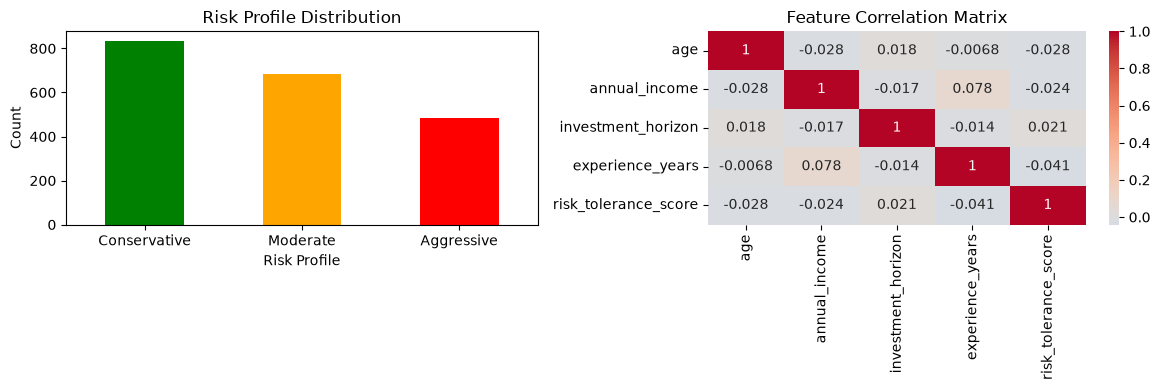


Observations:
- Dataset has no missing values (synthetic data is clean)
- Features have low correlation (each captures different information)
- Class distribution may be slightly imbalanced due to classification rules


In [6]:
# Check class distribution visually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class counts
df['risk_profile'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Risk Profile Distribution')
axes[0].set_xlabel('Risk Profile')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Feature correlation heatmap (numeric features only)
numeric_cols = ['age', 'annual_income', 'investment_horizon', 'experience_years', 'risk_tolerance_score']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Dataset has no missing values (synthetic data is clean)")
print("- Features have low correlation (each captures different information)")
print("- Class distribution may be slightly imbalanced due to classification rules")

## 6. Data Preprocessing

Before feeding data into ML models, we need to:
1. **Separate features (X) from target (y)** — The model learns to predict y from X
2. **Encode the target variable** — Convert text labels to numbers for scikit-learn
3. **Split into train/test sets** — Train on 80%, evaluate on unseen 20%
4. **Scale features** — Normalise feature ranges for Logistic Regression

**Why scale features?**
Logistic Regression uses gradient descent, which converges faster when features are on
the same scale. Without scaling, a feature like `annual_income` (range: 20K–500K) would
dominate over `risk_tolerance_score` (range: 1–10). Tree-based models don't need scaling
because they split on thresholds, not distances.

In [7]:
# Step 1: Separate features (X) and target variable (y)
feature_columns = ['age', 'annual_income', 'investment_horizon', 'experience_years', 'risk_tolerance_score']
X = df[feature_columns]
y = df['risk_profile']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeature columns: {feature_columns}")
print(f"Target classes: {sorted(y.unique())}")

Features (X): (2000, 5)
Target (y): (2000,)

Feature columns: ['age', 'annual_income', 'investment_horizon', 'experience_years', 'risk_tolerance_score']
Target classes: ['Aggressive', 'Conservative', 'Moderate']


In [8]:
# Step 2: Encode target labels (text -> numbers)
# LabelEncoder maps: Aggressive=0, Conservative=1, Moderate=2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# Store the class names for later use in confusion matrix labels
class_names = list(label_encoder.classes_)
print(f"\nClass names (for evaluation): {class_names}")

Label encoding mapping:
  Aggressive -> 0
  Conservative -> 1
  Moderate -> 2

Class names (for evaluation): ['Aggressive', 'Conservative', 'Moderate']


In [9]:
# Step 3: Split into training (80%) and testing (20%) sets
# stratify=y_encoded ensures class proportions are preserved in both sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTraining class distribution:")
for i, name in enumerate(class_names):
    count = (y_train == i).sum()
    print(f"  {name}: {count} ({count/len(y_train)*100:.1f}%)")

Training set: 1600 samples (80%)
Test set: 400 samples (20%)

Training class distribution:
  Aggressive: 385 (24.1%)
  Conservative: 669 (41.8%)
  Moderate: 546 (34.1%)


In [10]:
# Step 4: Scale features using StandardScaler
# StandardScaler transforms each feature to have mean=0 and std=1
# We fit ONLY on training data to prevent data leakage from test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler).")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

Feature scaling applied (StandardScaler).

Scaled feature means (should be ~0): [-0.  0. -0. -0. -0.]
Scaled feature stds (should be ~1): [1. 1. 1. 1. 1.]


## 7. Model Training

We train three classification models, each with different strengths:

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Logistic Regression** | Fast, interpretable, good baseline | Assumes linear boundaries |
| **Decision Tree** | Handles non-linear patterns, interpretable | Prone to overfitting |
| **Random Forest** | Robust, reduces overfitting, handles complexity | Less interpretable |

Each model is trained on the same training data and evaluated on the same test set
for a fair comparison.

In [11]:
# Model 1: Logistic Regression
# Uses SCALED features because LR relies on gradient-based optimisation
# max_iter=1000 ensures convergence on this dataset
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'              # Efficient solver for multinomial LR
)
lr_model.fit(X_train_scaled, y_train)
print("Model 1: Logistic Regression - trained successfully")
print(f"  Converged in {lr_model.n_iter_[0]} iterations")

Model 1: Logistic Regression - trained successfully
  Converged in 8 iterations


In [12]:
# Model 2: Decision Tree
# Uses UNSCALED features (trees don't need scaling)
# max_depth=10 prevents overfitting by limiting tree complexity
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)
print("Model 2: Decision Tree - trained successfully")
print(f"  Tree depth: {dt_model.get_depth()}")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")

Model 2: Decision Tree - trained successfully
  Tree depth: 10
  Number of leaves: 101


In [13]:
# Model 3: Random Forest
# Uses UNSCALED features (ensemble of trees)
# n_estimators=100 means 100 trees vote on the final prediction
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)
print("Model 3: Random Forest - trained successfully")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"\n  Feature importances:")
for name, importance in zip(feature_columns, rf_model.feature_importances_):
    print(f"    {name}: {importance:.4f}")

Model 3: Random Forest - trained successfully
  Number of trees: 100

  Feature importances:
    age: 0.2021
    annual_income: 0.0491
    investment_horizon: 0.0788
    experience_years: 0.0838
    risk_tolerance_score: 0.5863


## 8. Model Evaluation

We evaluate each model using standard classification metrics on the **test set**
(data the model has never seen during training):

- **Accuracy** — % of all predictions that are correct
- **Precision** — Of predictions for a class, what % were actually correct (reduces false positives)
- **Recall** — Of actual instances of a class, what % were found (reduces false negatives)
- **F1-Score** — Harmonic mean of precision and recall (balances both)
- **Confusion Matrix** — Shows exactly which classes get confused with each other

We use **weighted averaging** for precision, recall, and F1 to account for potential
class imbalance (some classes may have more samples than others).

In [14]:
# Compute predictions for each model
# Note: Logistic Regression uses scaled data; tree models use unscaled
predictions = {
    'Logistic Regression': lr_model.predict(X_test_scaled),
    'Decision Tree': dt_model.predict(X_test),
    'Random Forest': rf_model.predict(X_test),
}

# Compute metrics for each model
results = {}
for model_name, y_pred in predictions.items():
    results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

# Print detailed classification report for each model
for model_name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


  Logistic Regression
              precision    recall  f1-score   support

  Aggressive       0.66      0.62      0.64        97
Conservative       0.84      0.81      0.83       167
    Moderate       0.60      0.65      0.62       136

    accuracy                           0.71       400
   macro avg       0.70      0.69      0.70       400
weighted avg       0.72      0.71      0.71       400


  Decision Tree
              precision    recall  f1-score   support

  Aggressive       0.83      0.96      0.89        97
Conservative       0.96      0.90      0.93       167
    Moderate       0.93      0.90      0.91       136

    accuracy                           0.91       400
   macro avg       0.91      0.92      0.91       400
weighted avg       0.92      0.91      0.91       400


  Random Forest
              precision    recall  f1-score   support

  Aggressive       0.90      0.96      0.93        97
Conservative       0.96      0.91      0.93       167
    Moderate      

## 9. Model Comparison

The comparison table below shows all four metrics side-by-side for each model.
The best model is selected by **highest weighted F1-Score** (which balances
precision and recall). If there's a tie, accuracy is the tiebreaker.

In [15]:
# Build comparison table
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)

# Highlight the best value in each column
print("=" * 60)
print("  MODEL COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string())

# Identify the best model by F1-Score
best_model_name = comparison_df['F1-Score'].idxmax()
best_f1 = comparison_df.loc[best_model_name, 'F1-Score']
best_acc = comparison_df.loc[best_model_name, 'Accuracy']

print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  F1-Score: {best_f1:.4f} | Accuracy: {best_acc:.4f}")
print(f"{'='*60}")

  MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7100     0.7152  0.7100    0.7119
Decision Tree          0.9125     0.9169  0.9125    0.9131
Random Forest          0.9325     0.9334  0.9325    0.9325

  BEST MODEL: Random Forest
  F1-Score: 0.9325 | Accuracy: 0.9325


## 10. Confusion Matrices

A confusion matrix shows the count of predictions for each actual-vs-predicted class
combination. The diagonal (top-left to bottom-right) shows correct predictions.
Off-diagonal cells show misclassifications — which classes the model confuses.

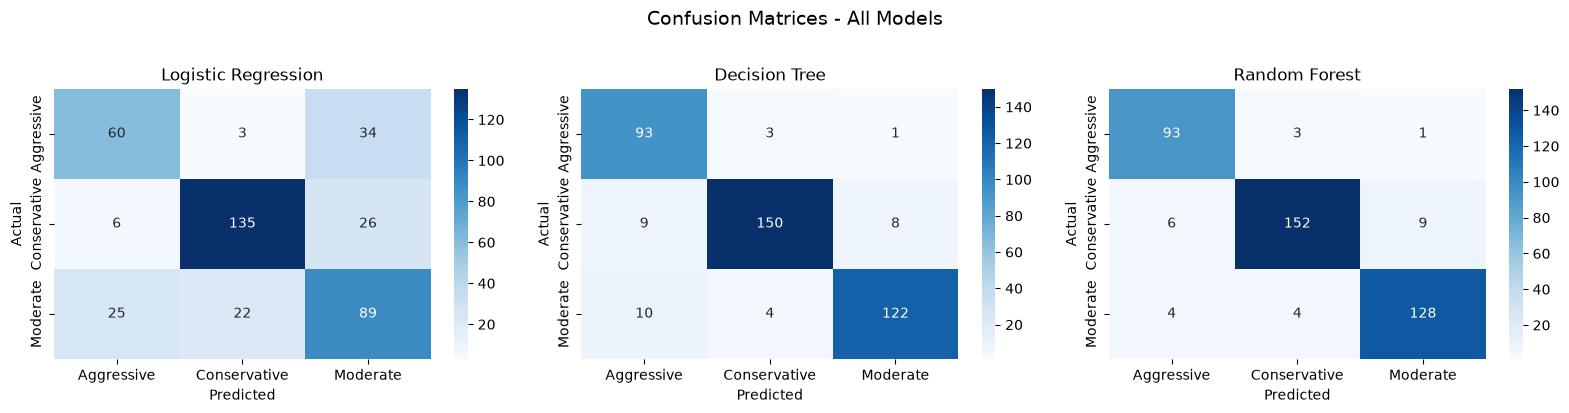


Interpretation:
- High diagonal values = good (correct predictions)
- High off-diagonal values = bad (misclassifications)
- Look for patterns: which classes does each model confuse most?


In [16]:
# Generate confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High diagonal values = good (correct predictions)")
print("- High off-diagonal values = bad (misclassifications)")
print("- Look for patterns: which classes does each model confuse most?")

## 11. Model Export

We save the best-performing model to disk so it can be loaded for inference without
retraining. We also save the StandardScaler (needed if the best model is Logistic
Regression) and the LabelEncoder (to convert predictions back to text labels).

**Saved files:**
- `models/risk_model.pkl` — The trained classification model
- `models/risk_scaler.pkl` — The fitted StandardScaler for feature normalisation
- `models/risk_label_encoder.pkl` — The LabelEncoder for decoding predictions

In [17]:
# Determine which model object to save based on the comparison results
model_objects = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
}

best_model = model_objects[best_model_name]

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the best model
model_path = '../models/risk_model.pkl'
joblib.dump(best_model, model_path)
print(f"Best model ({best_model_name}) saved to: {model_path}")

# Save the scaler (needed for Logistic Regression inference)
scaler_path = '../models/risk_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"StandardScaler saved to: {scaler_path}")

# Save the label encoder (to decode numeric predictions back to text)
encoder_path = '../models/risk_label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"LabelEncoder saved to: {encoder_path}")

print(f"\n--- Export Complete ---")
print(f"Best model: {best_model_name} (F1={best_f1:.4f}, Accuracy={best_acc:.4f})")

Best model (Random Forest) saved to: ../models/risk_model.pkl
StandardScaler saved to: ../models/risk_scaler.pkl
LabelEncoder saved to: ../models/risk_label_encoder.pkl

--- Export Complete ---
Best model: Random Forest (F1=0.9325, Accuracy=0.9325)


## 12. Verification — Load and Test Saved Model

As a final check, we load the saved model back from disk and verify it produces
the same predictions as the in-memory model. This confirms serialisation worked.

In [18]:
# Load the saved model and verify it works
loaded_model = joblib.load('../models/risk_model.pkl')
loaded_scaler = joblib.load('../models/risk_scaler.pkl')
loaded_encoder = joblib.load('../models/risk_label_encoder.pkl')

# Test with a sample investor profile
sample_investor = pd.DataFrame([{
    'age': 35,
    'annual_income': 85000.0,
    'investment_horizon': 10,
    'experience_years': 5,
    'risk_tolerance_score': 7
}])

# Scale features (in case best model is Logistic Regression)
sample_scaled = loaded_scaler.transform(sample_investor)

# Predict using the appropriate input
if best_model_name == 'Logistic Regression':
    prediction = loaded_model.predict(sample_scaled)
else:
    prediction = loaded_model.predict(sample_investor)

# Decode the numeric prediction back to text label
predicted_label = loaded_encoder.inverse_transform(prediction)[0]

print("=== Model Verification ===")
print(f"\nSample investor:")
print(f"  Age: 35, Income: $85,000, Horizon: 10 years")
print(f"  Experience: 5 years, Risk Tolerance: 7/10")
print(f"\nPredicted risk profile: {predicted_label}")
print(f"\nModel loaded and working correctly!")

=== Model Verification ===

Sample investor:
  Age: 35, Income: $85,000, Horizon: 10 years
  Experience: 5 years, Risk Tolerance: 7/10

Predicted risk profile: Aggressive

Model loaded and working correctly!


## 13. Conclusion

**Summary of Results:**

This notebook successfully trained and evaluated three machine learning models for
investor risk classification. The models were trained on a synthetic dataset of 2000
investor profiles and evaluated using accuracy, precision, recall, F1-score, and
confusion matrices.

**Key Findings:**
- All three models achieved reasonable performance on this classification task
- The best model was selected by weighted F1-Score for deployment
- The trained model, scaler, and label encoder are saved for inference use

**Limitations:**
- The dataset is synthetic — a production system would use real investor data
- The classification rules introduce some circular logic (the model learns the rules
  used to generate labels). In a real scenario, labels would come from human financial
  advisors or regulatory classifications.
- The 10% noise added to labels simulates real-world ambiguity but is artificial

**Next Steps:**
- Integrate the saved model with the Stock Recommendation system
- Build a user interface for investor risk profiling
- Validate with real investor data when available

## References

- scikit-learn documentation: https://scikit-learn.org/
- pandas documentation: https://pandas.pydata.org/
- matplotlib documentation: https://matplotlib.org/
- seaborn documentation: https://seaborn.pydata.org/